In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from ISUILCC_NMCGr_Data import Dataset_ISUILCC_NMCGr

c:\Users\pgasper\AppData\Local\anaconda3\envs\cannele\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
data = Dataset_ISUILCC_NMCGr(is_short=True)

Processing cell G1C1
Processing cell G2C4
Processing cell G49C3
Processing cell G50C3


In [3]:
df = data.get_dataset_summary_table()
df = df[df['measurement_type'] == 'RPT C_5']
df

,DeltaV_SOC_90SOC,charge_cv_time_frac,discharge_dQdV_3450mV,discharge_energy,discharge_QV_3420mV,discharge_QV_4000mV,DeltaV_SOC_max,discharge_dQdV_3580mV,charge_cc_time,discharge_dQdV_3805mV,...,cell_id,mean_C_chg,mean_C_dis,DoD,Stress_charge,Stress_discharge,Stress_avg,GroupNumber,weeks_to_80percent_C_5_capacity,log_weeks_to_80percent_C_5_capacity
0,0.109417,0.055443,-0.266210,1.049722,0.261825,0.036765,0.275139,-0.439527,19609.0,-0.480861,...,G1C1,0.49680,-0.498113,0.246153,0.349698,0.350160,0.349929,1,39,3.663562
2,0.085642,0.043175,-0.298675,1.049719,0.261896,0.044018,0.207622,-0.449701,19635.0,-0.454333,...,G1C1,0.49680,-0.498113,0.246153,0.349698,0.350160,0.349929,1,39,3.663562
4,0.081793,0.041516,-0.306817,1.044846,0.260700,0.045525,0.181962,-0.441571,19555.0,-0.451777,...,G1C1,0.49680,-0.498113,0.246153,0.349698,0.350160,0.349929,1,39,3.663562
6,0.079710,0.040138,-0.310909,1.040124,0.259478,0.046069,0.163954,-0.435453,19490.0,-0.450681,...,G1C1,0.49680,-0.498113,0.246153,0.349698,0.350160,0.349929,1,39,3.663562
8,0.077955,0.039732,-0.326063,1.038715,0.259087,0.046113,0.152776,-0.433531,19480.0,-0.449603,...,G1C1,0.49680,-0.498113,0.246153,0.349698,0.350160,0.349929,1,39,3.663562
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
294,0.127062,0.082863,-0.146050,0.724002,0.176159,0.024908,0.251498,-0.204189,13160.0,-0.347270,...,G50C3,0.25155,-1.625531,0.174268,0.209373,0.532238,0.370806,50,26,3.258097
296,0.137029,0.094965,-0.138493,0.690918,0.167607,0.022736,0.258637,-0.182786,12475.0,-0.342107,...,G50C3,0.25155,-1.625531,0.174268,0.209373,0.532238,0.370806,50,26,3.258097
298,0.150552,0.111196,-0.130704,0.651794,0.157415,0.019876,0.269268,-0.164895,11670.0,-0.330951,...,G50C3,0.25155,-1.625531,0.174268,0.209373,0.532238,0.370806,50,26,3.258097
300,0.164866,0.127593,-0.120012,0.610470,0.146828,0.017225,0.280686,-0.147044,10810.0,-0.319806,...,G50C3,0.25155,-1.625531,0.174268,0.209373,0.532238,0.370806,50,26,3.258097


All matrix extraction methods return two outputs:
- a `list` of cell_ids for each row of any x and y pair(s)
- `tuple`(s) of x-y pair(s), where both `x` and `y` are `pd.DataFrame`s

For each given type of model, the result may be a single list of cell_ids and a single (x,y) tuple, or a list of lists of cell_ids and a list of (x,y) tuples:
- `get_failure_matrices`: failure prediction models use data from measurement N to predict a single target (presumed to be some information about cell failure, like time to failure or capacity at the final measurement). So for each measurement 1:N in a data set, there is a separate model, with a potentially variable number of cells depending on which cells have valid data at a given measurement number (they may fail at different times, for instance).
    - the output is list of cell_id lists, and a list of (x,y) tuples for each measurement number
- `get_rul_matrices`: remaining useful life (RUL) models use data from measurement N to predict the remaining measurements until failure (or some other user-defined 'tracking' variable). Unlike the failure prediction model, this means that all data from all measurements of every cell can simply be stacked together, though the relationships the model will need to learn may be more complicated than a failure prediction model.
    - the output is list of cell_ids for each row in x and y, and the single (x,y) tuple
- `get_lookahead_matrices`: look-ahead prediction models use data from measurement N to predict the target at some measurement N+t. So for each measurement 1:N in a data set, and for each number of 'look-aheads' t, there is a separate model, with a potentially variable number of cells depending on which cells have valid data at a given measurement number and valid data at the future measurement N+t.
    - the output is a list of cell_id lsits, and a list of (x,y) tuples for each measurement number
- `get_autoregressive_matrices`: autoregressive models use data from any measurement to predict the target at some future measurement, i.e., always predicting the target at some future time regardless of where the current measurement is in the testing sequence. The input data can be just the data from the current measurement, or there can be additional data from 'lags', i.e., data from past as well as current measurements. Often, both the lagged input data as well as the targets are differences from the current values for autoregressive models (this is an optional input; best practices vary based on the specific prediction problem). Unlike the 'look-ahead' prediction problem, this means that all data from all measurements (well, all expect the first 'lags' measurements of each cell) can simply be stacked together, though the relationships the model will need to learn may be more complicated than a failure prediction model.
    - the output is a list of cell_ids for each row in x and y, and a single (x,y) tuple
- `get_trajectory_matrices`: trajectory models simply predict the trajectory of a single target from a single chronological variable, like time, cycle count, or measurement number; basically, just predicting the change of a single variable over time, like `y = a*time + b`. Each trajectory of each cell is unique.
    - the output is a list of cell_ids for each (x,y) tuple, and list of (x,y) tuples, one for each cell

In [4]:
cell_ids, xy_pairs = data.get_failure_matrices()

In [5]:
len(cell_ids), len(xy_pairs)

(51, 51)

In [6]:
for cells, (x, y) in zip(cell_ids, xy_pairs):
    print(len(cells), len(x), len(y))

4 4 4
4 4 4
4 4 4
4 4 4
4 4 4
4 4 4
4 4 4
4 4 4
4 4 4
4 4 4
4 4 4
4 4 4
4 4 4
4 4 4
4 4 4
4 4 4
4 4 4
4 4 4
4 4 4
4 4 4
4 4 4
4 4 4
4 4 4
4 4 4
4 4 4
4 4 4
4 4 4
3 3 3
3 3 3
3 3 3
3 3 3
3 3 3
3 3 3
3 3 3
2 2 2
2 2 2
1 1 1
1 1 1
1 1 1
1 1 1
1 1 1
1 1 1
1 1 1
1 1 1
1 1 1
1 1 1
1 1 1
1 1 1
1 1 1
1 1 1
1 1 1


In [7]:
cell_ids

[['G1C1', 'G2C4', 'G49C3', 'G50C3'],
 ['G1C1', 'G2C4', 'G49C3', 'G50C3'],
 ['G1C1', 'G2C4', 'G49C3', 'G50C3'],
 ['G1C1', 'G2C4', 'G49C3', 'G50C3'],
 ['G1C1', 'G2C4', 'G49C3', 'G50C3'],
 ['G1C1', 'G2C4', 'G49C3', 'G50C3'],
 ['G1C1', 'G2C4', 'G49C3', 'G50C3'],
 ['G1C1', 'G2C4', 'G49C3', 'G50C3'],
 ['G1C1', 'G2C4', 'G49C3', 'G50C3'],
 ['G1C1', 'G2C4', 'G49C3', 'G50C3'],
 ['G1C1', 'G2C4', 'G49C3', 'G50C3'],
 ['G1C1', 'G2C4', 'G49C3', 'G50C3'],
 ['G1C1', 'G2C4', 'G49C3', 'G50C3'],
 ['G1C1', 'G2C4', 'G49C3', 'G50C3'],
 ['G1C1', 'G2C4', 'G49C3', 'G50C3'],
 ['G1C1', 'G2C4', 'G49C3', 'G50C3'],
 ['G1C1', 'G2C4', 'G49C3', 'G50C3'],
 ['G1C1', 'G2C4', 'G49C3', 'G50C3'],
 ['G1C1', 'G2C4', 'G49C3', 'G50C3'],
 ['G1C1', 'G2C4', 'G49C3', 'G50C3'],
 ['G1C1', 'G2C4', 'G49C3', 'G50C3'],
 ['G1C1', 'G2C4', 'G49C3', 'G50C3'],
 ['G1C1', 'G2C4', 'G49C3', 'G50C3'],
 ['G1C1', 'G2C4', 'G49C3', 'G50C3'],
 ['G1C1', 'G2C4', 'G49C3', 'G50C3'],
 ['G1C1', 'G2C4', 'G49C3', 'G50C3'],
 ['G1C1', 'G2C4', 'G49C3', 'G50C3'],
 

In [8]:
# x-y pairs are always tuples (x,y), where the 0th element is x and the 1st element is y
xy_pairs[0][0]

,num_week,log_abs_delta_DeltaV_SOC_70SOC_C_5,repeat_num,discharge_delta_QV_3420mV_C_5,DeltaV_SOC_max,discharge_dQdV_3580mV,log_abs_delta_DeltaV_SOC_30SOC_C_5,charge_cc_time,discharge_dQdV_3860mV,charge_log_var_delta_QV_C_5,...,coulombic_efficiency,log_relative_discharge_energy_C_5,discharge_log_abs_delta_dQdV_3860mV_C_5,energy_inefficiency,log_relative_discharge_capacity_fade_C_5,discharge_delta_dQdV_3860mV_C_5,charge_cv_time,relative_DeltaV_SOC_3SOC_C_5,DeltaV_SOC_SOC_at_max,discharge_log_abs_delta_QV_3700mV_C_5
0,1,-3.602275,2,0.000071,0.207622,-0.449701,-4.752102,19635.0,-0.476994,-12.665034,...,1.004663,-0.000003,-4.142054,0.018583,-6.145579,0.015890,886.0,0.930500,0.005005,-6.603971
1,1,-3.609123,2,-0.002936,0.205332,-0.450098,-4.975022,19634.0,-0.412252,-12.978559,...,1.003225,-0.011042,-2.707892,0.018507,-4.430516,0.066677,745.0,0.956602,0.005005,-5.794887
2,1,-3.813206,2,-0.000807,0.217680,-0.432592,-7.226863,19419.0,-0.434075,-14.100886,...,1.004789,-0.000659,-2.956900,0.025052,-6.287486,0.051980,1075.0,0.971481,0.003003,-7.856270
3,1,-3.723013,2,-0.003292,0.186106,-0.428105,-5.892652,19540.0,-0.459616,-12.856441,...,1.006308,-0.009582,-3.263061,0.016707,-4.498652,0.038271,792.0,0.970707,0.004004,-10.064207


In [9]:
xy_pairs[0][1]

,log_weeks_to_80percent_C_5_capacity
0,3.663562
1,2.995732
2,3.332205
3,3.258097


In [10]:
cell_ids, (x, y) = data.get_rul_matrices()

In [11]:
len(cell_ids), len(x), len(y)

(109, 109, 109)

In [12]:
cell_ids

['G1C1',
 'G1C1',
 'G1C1',
 'G1C1',
 'G1C1',
 'G1C1',
 'G1C1',
 'G1C1',
 'G1C1',
 'G1C1',
 'G1C1',
 'G1C1',
 'G1C1',
 'G1C1',
 'G1C1',
 'G1C1',
 'G1C1',
 'G1C1',
 'G1C1',
 'G1C1',
 'G1C1',
 'G1C1',
 'G1C1',
 'G1C1',
 'G1C1',
 'G1C1',
 'G1C1',
 'G1C1',
 'G1C1',
 'G1C1',
 'G1C1',
 'G1C1',
 'G1C1',
 'G1C1',
 'G1C1',
 'G1C1',
 'G1C1',
 'G1C1',
 'G2C4',
 'G2C4',
 'G2C4',
 'G2C4',
 'G2C4',
 'G2C4',
 'G2C4',
 'G2C4',
 'G2C4',
 'G2C4',
 'G2C4',
 'G2C4',
 'G2C4',
 'G2C4',
 'G2C4',
 'G2C4',
 'G2C4',
 'G2C4',
 'G2C4',
 'G49C3',
 'G49C3',
 'G49C3',
 'G49C3',
 'G49C3',
 'G49C3',
 'G49C3',
 'G49C3',
 'G49C3',
 'G49C3',
 'G49C3',
 'G49C3',
 'G49C3',
 'G49C3',
 'G49C3',
 'G49C3',
 'G49C3',
 'G49C3',
 'G49C3',
 'G49C3',
 'G49C3',
 'G49C3',
 'G49C3',
 'G49C3',
 'G49C3',
 'G49C3',
 'G49C3',
 'G50C3',
 'G50C3',
 'G50C3',
 'G50C3',
 'G50C3',
 'G50C3',
 'G50C3',
 'G50C3',
 'G50C3',
 'G50C3',
 'G50C3',
 'G50C3',
 'G50C3',
 'G50C3',
 'G50C3',
 'G50C3',
 'G50C3',
 'G50C3',
 'G50C3',
 'G50C3',
 'G50C3',
 'G50C3

In [13]:
x

,DeltaV_SOC_90SOC,charge_cv_time_frac,discharge_dQdV_3450mV,discharge_energy,discharge_QV_3420mV,discharge_QV_4000mV,DeltaV_SOC_max,discharge_dQdV_3580mV,charge_cc_time,discharge_dQdV_3805mV,...,var_delta_DeltaV_SOC_C_5,mean_delta_DeltaV_SOC_C_5,log_var_delta_DeltaV_SOC_C_5,num_week,measurement_type,start_time_s,start_time_day,cycle,charge_throughput_Ah,repeat_num
0,0.085642,0.043175,-0.298675,1.049719,0.261896,0.044018,0.207622,-0.449701,19635.0,-0.454333,...,0.000085,-0.016731,-9.373722,1,RPT C_5,691148.0,7.999398,3,1.656989,2
1,0.081793,0.041516,-0.306817,1.044846,0.260700,0.045525,0.181962,-0.441571,19555.0,-0.451777,...,0.000119,-0.019815,-9.032295,2,RPT C_5,1379548.0,15.966991,5,2.748323,3
2,0.079710,0.040138,-0.310909,1.040124,0.259478,0.046069,0.163954,-0.435453,19490.0,-0.450681,...,0.000154,-0.021807,-8.778742,3,RPT C_5,2079066.0,24.063264,7,3.836817,4
3,0.077955,0.039732,-0.326063,1.038715,0.259087,0.046113,0.152776,-0.433531,19480.0,-0.449603,...,0.000179,-0.022952,-8.628332,4,RPT C_5,2859701.0,33.098391,9,4.923457,5
4,0.077689,0.039594,-0.328146,1.034055,0.257753,0.045905,0.148885,-0.427902,19405.0,-0.452905,...,0.000193,-0.022888,-8.555319,5,RPT C_5,3694183.0,42.756748,11,6.006859,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
104,0.098432,0.054412,-0.212539,0.903346,0.220623,0.035265,0.226993,-0.329146,16770.0,-0.404929,...,0.000461,0.017678,-7.682629,21,RPT C_5,14171756.0,164.024954,43,22.013542,22
105,0.099795,0.055809,-0.210388,0.893982,0.218312,0.034615,0.225280,-0.322777,16580.0,-0.403785,...,0.000467,0.019198,-7.670144,22,RPT C_5,14861198.0,172.004606,45,22.960432,23
106,0.101031,0.057136,-0.206968,0.883668,0.215747,0.034065,0.224698,-0.315953,16370.0,-0.401330,...,0.000481,0.020649,-7.640578,23,RPT C_5,15555965.0,180.045891,47,23.896623,24
107,0.102583,0.058707,-0.204521,0.871854,0.212895,0.033315,0.223896,-0.307269,16130.0,-0.399859,...,0.000486,0.022581,-7.630164,24,RPT C_5,16254424.0,188.129907,49,24.820785,25


In [14]:
y

0      3.637586
1      3.610918
2      3.583519
3      3.555348
4      3.526361
         ...   
104    1.609438
105    1.386294
106    1.098612
107    0.693147
108    0.000000
Name: log_remaining_weeks_to_80percent_C_5_capacity, Length: 109, dtype: float64

In [15]:
cell_ids, xy_pairs = data.get_lookahead_matrices()

In [16]:
len(cell_ids), len(xy_pairs)

(50, 50)

In [17]:
for cells, (x, y) in zip(cell_ids, xy_pairs):
    print(len(cells), len(x), len(y))

4 4 4
4 4 4
4 4 4
4 4 4
4 4 4
4 4 4
4 4 4
4 4 4
4 4 4
4 4 4
4 4 4
4 4 4
4 4 4
4 4 4
4 4 4
4 4 4
4 4 4
4 4 4
4 4 4
4 4 4
4 4 4
4 4 4
4 4 4
4 4 4
4 4 4
4 4 4
3 3 3
3 3 3
3 3 3
3 3 3
3 3 3
3 3 3
3 3 3
2 2 2
2 2 2
1 1 1
1 1 1
1 1 1
1 1 1
1 1 1
1 1 1
1 1 1
1 1 1
1 1 1
1 1 1
1 1 1
1 1 1
1 1 1
1 1 1
1 1 1


In [18]:
cell_ids

[['G1C1', 'G2C4', 'G49C3', 'G50C3'],
 ['G1C1', 'G2C4', 'G49C3', 'G50C3'],
 ['G1C1', 'G2C4', 'G49C3', 'G50C3'],
 ['G1C1', 'G2C4', 'G49C3', 'G50C3'],
 ['G1C1', 'G2C4', 'G49C3', 'G50C3'],
 ['G1C1', 'G2C4', 'G49C3', 'G50C3'],
 ['G1C1', 'G2C4', 'G49C3', 'G50C3'],
 ['G1C1', 'G2C4', 'G49C3', 'G50C3'],
 ['G1C1', 'G2C4', 'G49C3', 'G50C3'],
 ['G1C1', 'G2C4', 'G49C3', 'G50C3'],
 ['G1C1', 'G2C4', 'G49C3', 'G50C3'],
 ['G1C1', 'G2C4', 'G49C3', 'G50C3'],
 ['G1C1', 'G2C4', 'G49C3', 'G50C3'],
 ['G1C1', 'G2C4', 'G49C3', 'G50C3'],
 ['G1C1', 'G2C4', 'G49C3', 'G50C3'],
 ['G1C1', 'G2C4', 'G49C3', 'G50C3'],
 ['G1C1', 'G2C4', 'G49C3', 'G50C3'],
 ['G1C1', 'G2C4', 'G49C3', 'G50C3'],
 ['G1C1', 'G2C4', 'G49C3', 'G50C3'],
 ['G1C1', 'G2C4', 'G49C3', 'G50C3'],
 ['G1C1', 'G2C4', 'G49C3', 'G50C3'],
 ['G1C1', 'G2C4', 'G49C3', 'G50C3'],
 ['G1C1', 'G2C4', 'G49C3', 'G50C3'],
 ['G1C1', 'G2C4', 'G49C3', 'G50C3'],
 ['G1C1', 'G2C4', 'G49C3', 'G50C3'],
 ['G1C1', 'G2C4', 'G49C3', 'G50C3'],
 ['G1C1', 'G49C3', 'G50C3'],
 ['G1C1',

In [19]:
xy_pairs[0][0]

,num_week,log_abs_delta_DeltaV_SOC_70SOC_C_5,repeat_num,discharge_delta_QV_3420mV_C_5,DeltaV_SOC_max,discharge_dQdV_3580mV,log_abs_delta_DeltaV_SOC_30SOC_C_5,charge_cc_time,discharge_dQdV_3860mV,charge_log_var_delta_QV_C_5,...,coulombic_efficiency,log_relative_discharge_energy_C_5,discharge_log_abs_delta_dQdV_3860mV_C_5,energy_inefficiency,log_relative_discharge_capacity_fade_C_5,discharge_delta_dQdV_3860mV_C_5,charge_cv_time,relative_DeltaV_SOC_3SOC_C_5,DeltaV_SOC_SOC_at_max,discharge_log_abs_delta_QV_3700mV_C_5
0,1,-3.602275,2,0.000071,0.207622,-0.449701,-4.752102,19635.0,-0.476994,-12.665034,...,1.004663,-0.000003,-4.142054,0.018583,-6.145579,0.015890,886.0,0.930500,0.005005,-6.603971
1,1,-3.609123,2,-0.002936,0.205332,-0.450098,-4.975022,19634.0,-0.412252,-12.978559,...,1.003225,-0.011042,-2.707892,0.018507,-4.430516,0.066677,745.0,0.956602,0.005005,-5.794887
2,1,-3.813206,2,-0.000807,0.217680,-0.432592,-7.226863,19419.0,-0.434075,-14.100886,...,1.004789,-0.000659,-2.956900,0.025052,-6.287486,0.051980,1075.0,0.971481,0.003003,-7.856270
3,1,-3.723013,2,-0.003292,0.186106,-0.428105,-5.892652,19540.0,-0.459616,-12.856441,...,1.006308,-0.009582,-3.263061,0.016707,-4.498652,0.038271,792.0,0.970707,0.004004,-10.064207


In [20]:
xy_pairs[0][1]

repeat_num,3,4,5,6,7,8,9,10,11,12,...,43,44,45,46,47,48,49,50,51,52
0,0.992949,0.988354,0.987175,0.982908,0.977209,0.971773,0.970247,0.967212,0.960997,0.958023,...,0.718429,0.690862,0.654426,0.617483,0.590783,0.567154,0.541939,0.511402,0.488945,0.456883
1,0.976464,0.967078,0.960087,0.950928,0.942222,0.934467,0.927757,0.919953,0.909177,0.898989,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.994737,0.985310,0.975376,0.967722,0.961754,0.955298,0.947854,0.941490,0.935705,0.928924,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0.980360,0.964190,0.951248,0.941455,0.934183,0.927328,0.920442,0.915243,0.911372,0.906431,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [21]:
cell_ids, (x, y) = data.get_autoregressive_matrices()

In [22]:
len(cell_ids), len(x), len(y)

(140, 140, 140)

In [23]:
cell_ids

['G1C1',
 'G1C1',
 'G1C1',
 'G1C1',
 'G1C1',
 'G1C1',
 'G1C1',
 'G1C1',
 'G1C1',
 'G1C1',
 'G1C1',
 'G1C1',
 'G1C1',
 'G1C1',
 'G1C1',
 'G1C1',
 'G1C1',
 'G1C1',
 'G1C1',
 'G1C1',
 'G1C1',
 'G1C1',
 'G1C1',
 'G1C1',
 'G1C1',
 'G1C1',
 'G1C1',
 'G1C1',
 'G1C1',
 'G1C1',
 'G1C1',
 'G1C1',
 'G1C1',
 'G1C1',
 'G1C1',
 'G1C1',
 'G1C1',
 'G1C1',
 'G1C1',
 'G1C1',
 'G1C1',
 'G1C1',
 'G1C1',
 'G1C1',
 'G1C1',
 'G1C1',
 'G1C1',
 'G1C1',
 'G1C1',
 'G2C4',
 'G2C4',
 'G2C4',
 'G2C4',
 'G2C4',
 'G2C4',
 'G2C4',
 'G2C4',
 'G2C4',
 'G2C4',
 'G2C4',
 'G2C4',
 'G2C4',
 'G2C4',
 'G2C4',
 'G2C4',
 'G2C4',
 'G2C4',
 'G2C4',
 'G2C4',
 'G2C4',
 'G2C4',
 'G2C4',
 'G2C4',
 'G2C4',
 'G49C3',
 'G49C3',
 'G49C3',
 'G49C3',
 'G49C3',
 'G49C3',
 'G49C3',
 'G49C3',
 'G49C3',
 'G49C3',
 'G49C3',
 'G49C3',
 'G49C3',
 'G49C3',
 'G49C3',
 'G49C3',
 'G49C3',
 'G49C3',
 'G49C3',
 'G49C3',
 'G49C3',
 'G49C3',
 'G49C3',
 'G49C3',
 'G49C3',
 'G49C3',
 'G49C3',
 'G49C3',
 'G49C3',
 'G49C3',
 'G49C3',
 'G49C3',
 'G49C3',
 'G4

In [24]:
x

,DeltaV_SOC_90SOC,charge_cv_time_frac,discharge_dQdV_3450mV,discharge_energy,discharge_QV_3420mV,discharge_QV_4000mV,DeltaV_SOC_max,discharge_dQdV_3580mV,charge_cc_time,discharge_dQdV_3805mV,...,charge_log_abs_mean_delta_dQdV_C_5_lag1,var_delta_DeltaV_SOC_C_5_lag1,mean_delta_DeltaV_SOC_C_5_lag1,log_var_delta_DeltaV_SOC_C_5_lag1,num_week_lag1,start_time_s_lag1,start_time_day_lag1,cycle_lag1,charge_throughput_Ah_lag1,repeat_num_lag1
0,0.081793,0.041516,-0.306817,1.044846,0.260700,0.045525,0.181962,-0.441571,19555.0,-0.451777,...,0.395849,-0.000035,0.003084,-0.341428,-1.0,-688400.0,-7.967593,-2.0,-1.091334,-1.0
1,0.079710,0.040138,-0.310909,1.040124,0.259478,0.046069,0.163954,-0.435453,19490.0,-0.450681,...,0.375556,-0.000034,0.001993,-0.253553,-1.0,-699518.0,-8.096273,-2.0,-1.088495,-1.0
2,0.077955,0.039732,-0.326063,1.038715,0.259087,0.046113,0.152776,-0.433531,19480.0,-0.449603,...,0.246033,-0.000025,0.001145,-0.150409,-1.0,-780635.0,-9.035127,-2.0,-1.086640,-1.0
3,0.077689,0.039594,-0.328146,1.034055,0.257753,0.045905,0.148885,-0.427902,19405.0,-0.452905,...,1.516927,-0.000014,-0.000064,-0.073013,-1.0,-834482.0,-9.658356,-2.0,-1.083401,-1.0
4,0.077243,0.039936,-0.322587,1.028136,0.256218,0.045956,0.146157,-0.423684,19280.0,-0.449813,...,-1.446746,-0.000013,-0.000052,-0.065635,-1.0,-799538.0,-9.253912,-2.0,-1.075683,-1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
135,0.119983,0.075423,-0.160647,0.757427,0.184790,0.026798,0.239223,-0.221096,13840.0,-0.366186,...,-0.111008,-0.000078,-0.004986,-0.126606,-1.0,-685469.0,-7.933669,-2.0,-0.809911,-1.0
136,0.127062,0.082863,-0.146050,0.724002,0.176159,0.024908,0.251498,-0.204189,13160.0,-0.347270,...,-0.104937,-0.000120,-0.006762,-0.167758,-1.0,-793991.0,-9.189711,-2.0,-0.774205,-1.0
137,0.137029,0.094965,-0.138493,0.690918,0.167607,0.022736,0.258637,-0.182786,12475.0,-0.342107,...,-0.099642,-0.000086,-0.009793,-0.104375,-1.0,-743150.0,-8.601273,-2.0,-0.736833,-1.0
138,0.150552,0.111196,-0.130704,0.651794,0.157415,0.019876,0.269268,-0.164895,11670.0,-0.330951,...,-0.107990,-0.000116,-0.012254,-0.125901,-1.0,-716965.0,-8.298206,-2.0,-0.695234,-1.0


In [ ]:
x[['relative_discharge_capacity_C_5', 'relative_discharge_capacity_C_5_lag1']]

,relative_discharge_capacity_C_5,relative_discharge_capacity_C_5_lag1
0,0.992949,0.004908
1,0.988354,0.004596
2,0.987175,0.001179
3,0.982908,0.004267
4,0.977209,0.005699
...,...,...
135,0.715998,0.030136
136,0.684108,0.031890
137,0.653049,0.031059
138,0.616740,0.036309


The y-matrix below is a bit confusing, maybe. Some explanation:
- Each row is measurement; all measurements from all cells are stacked on one another, as in the x matrix.
- Each column in y is the diff of the target from the current measurement to some future measurement, where each additional column is farther in the future.
    - so, for example, if [row 0 column 0] is 0.1, and [row 1 column 0] is 0.2, then [row 0 column 1] will be 0.3; the changes to the target are cumulative.
    - by default the calculated y is the diff of the targets, but you can turn that off by setting `is_diff_y=False` to just have absolute values of y
- As the current measurement number increases, more of the row turns into NaNs, as you cannot predict as far into the future when you're starting at a higher measurement number.

In [26]:
y

,0,1,2,3,4,5,6,7,8,9,...,39,40,41,42,43,44,45,46,47,48
0,-0.004596,-0.005774,-0.010042,-0.015741,-0.021176,-0.022702,-0.025737,-0.031953,-0.034926,-0.041074,...,-0.274520,-0.302087,-0.338524,-0.375467,-0.402167,-0.425795,-0.451010,-0.481547,-0.504004,-0.536066
1,-0.001179,-0.005446,-0.011145,-0.016581,-0.018107,-0.021141,-0.027357,-0.030331,-0.036478,-0.042663,...,-0.297491,-0.333928,-0.370871,-0.397571,-0.421200,-0.446414,-0.476951,-0.499409,-0.531471,NaN
2,-0.004267,-0.009966,-0.015402,-0.016928,-0.019962,-0.026178,-0.029152,-0.035300,-0.041484,-0.044075,...,-0.332749,-0.369692,-0.396392,-0.420021,-0.445236,-0.475773,-0.498230,-0.530292,NaN,NaN
3,-0.005699,-0.011135,-0.012661,-0.015695,-0.021911,-0.024884,-0.031032,-0.037216,-0.039808,-0.044097,...,-0.365425,-0.392125,-0.415753,-0.440968,-0.471505,-0.493963,-0.526025,NaN,NaN,NaN
4,-0.005436,-0.006962,-0.009996,-0.016212,-0.019186,-0.025333,-0.031518,-0.034109,-0.038398,-0.042316,...,-0.386426,-0.410055,-0.435269,-0.465806,-0.488264,-0.520326,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
135,-0.031890,-0.062949,-0.099258,-0.137870,-0.177833,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
136,-0.031059,-0.067368,-0.105979,-0.145943,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
137,-0.036309,-0.074920,-0.114884,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
138,-0.038612,-0.078575,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [27]:
cell_ids[45:60]

['G1C1',
 'G1C1',
 'G1C1',
 'G1C1',
 'G2C4',
 'G2C4',
 'G2C4',
 'G2C4',
 'G2C4',
 'G2C4',
 'G2C4',
 'G2C4',
 'G2C4',
 'G2C4',
 'G2C4']

In [28]:
y[45:60]

,0,1,2,3,4,5,6,7,8,9,...,39,40,41,42,43,44,45,46,47,48
45,-0.025215,-0.055752,-0.078209,-0.110271,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
46,-0.030537,-0.052994,-0.085057,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
47,-0.022457,-0.054520,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
48,-0.032062,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
49,-0.009386,-0.016377,-0.025536,-0.034242,-0.041997,-0.048708,-0.056512,-0.067287,-0.077476,-0.090438,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50,-0.006991,-0.016150,-0.024856,-0.032611,-0.039322,-0.047126,-0.057901,-0.068090,-0.081053,-0.095449,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
51,-0.009159,-0.017865,-0.025620,-0.032330,-0.040135,-0.050910,-0.061099,-0.074061,-0.088458,-0.098080,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
52,-0.008706,-0.016461,-0.023171,-0.030975,-0.041751,-0.051939,-0.064902,-0.079299,-0.088921,-0.100499,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
53,-0.007755,-0.014466,-0.022270,-0.033045,-0.043234,-0.056196,-0.070593,-0.080215,-0.091793,-0.097730,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
54,-0.006711,-0.014515,-0.025290,-0.035479,-0.048441,-0.062838,-0.072460,-0.084038,-0.089975,-0.092592,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


The x-matrix also deserves a bit of explanation:
- if is_diff_x, any features at lags greater than 1 are returned as the diff between that lag and the previous one; not the diff between each lag and the first lag.
- lags can be specified as a list, like [5, 10], if you want larger spaced lags. There are no rules on spacing, lags just have to be positive definite, and will be sorted before indexing the measurements.

In [29]:
cell_ids, (x, y) = data.get_autoregressive_matrices(n_lags=3, is_diff_x=True)
x[['relative_discharge_capacity_C_5', 'relative_discharge_capacity_C_5_lag1', 'relative_discharge_capacity_C_5_lag2']]

,relative_discharge_capacity_C_5,relative_discharge_capacity_C_5_lag1,relative_discharge_capacity_C_5_lag2
0,0.987175,0.004908,0.004596
1,0.982908,0.004596,0.001179
2,0.977209,0.001179,0.004267
3,0.971773,0.004267,0.005699
4,0.970247,0.005699,0.005436
...,...,...,...
127,0.715998,0.024648,0.025659
128,0.684108,0.025659,0.030136
129,0.653049,0.030136,0.031890
130,0.616740,0.031890,0.031059


In [30]:
cell_ids, (x, y) = data.get_autoregressive_matrices(n_lags=3, is_diff_x=False)
x[['relative_discharge_capacity_C_5', 'relative_discharge_capacity_C_5_lag1', 'relative_discharge_capacity_C_5_lag2']]

,relative_discharge_capacity_C_5,relative_discharge_capacity_C_5_lag1,relative_discharge_capacity_C_5_lag2
0,0.987175,0.988354,0.992949
1,0.982908,0.987175,0.988354
2,0.977209,0.982908,0.987175
3,0.971773,0.977209,0.982908
4,0.970247,0.971773,0.977209
...,...,...,...
127,0.715998,0.746135,0.771794
128,0.684108,0.715998,0.746135
129,0.653049,0.684108,0.715998
130,0.616740,0.653049,0.684108


In [31]:
cell_ids, (x, y) = data.get_autoregressive_matrices(n_lags=[2, 5, 10], is_diff_x=False)
x[['relative_discharge_capacity_C_5', 'relative_discharge_capacity_C_5_lag2', 'relative_discharge_capacity_C_5_lag5', 'relative_discharge_capacity_C_5_lag10']]

,relative_discharge_capacity_C_5,relative_discharge_capacity_C_5_lag2,relative_discharge_capacity_C_5_lag5,relative_discharge_capacity_C_5_lag10
0,0.958023,0.967212,0.977209,0.997857
1,0.951875,0.960997,0.971773,0.992949
2,0.945691,0.958023,0.970247,0.988354
3,0.943100,0.951875,0.967212,0.987175
4,0.938811,0.945691,0.960997,0.982908
...,...,...,...,...
99,0.715998,0.771794,0.826145,0.871176
100,0.684108,0.746135,0.813098,0.864474
101,0.653049,0.715998,0.796442,0.856215
102,0.616740,0.684108,0.771794,0.847308


In [32]:
cell_ids, xy_pairs = data.get_trajectory_matrices()

In [33]:
len(cell_ids), len(xy_pairs)

(4, 4)

In [34]:
cell_ids

['G1C1', 'G2C4', 'G49C3', 'G50C3']

In [35]:
xy_pairs[1][0]

,repeat_num
0,1
1,2
2,3
3,4
4,5
5,6
6,7
7,8
8,9
9,10


In [36]:
xy_pairs[1][1]

,relative_discharge_capacity_C_5
0,1.000000
1,0.988092
2,0.976464
3,0.967078
4,0.960087
5,0.950928
6,0.942222
7,0.934467
8,0.927757
9,0.919953


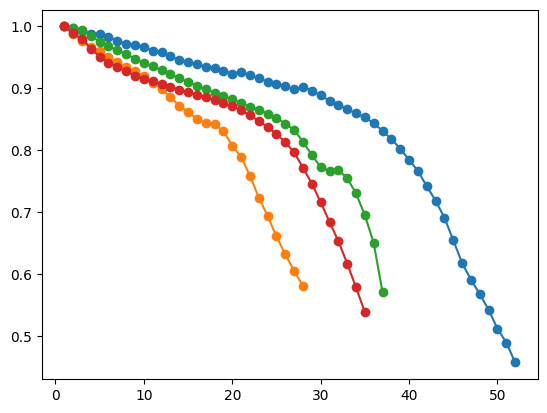

In [37]:
for xy in xy_pairs:
    plt.plot(xy[0], xy[1], '-o')